In [1]:
!pip install transformers[torch] fugashi sudachipy sudachidict_core

In [2]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

In [4]:
df = pd.read_excel('yahoo_news_21jul.xlsx', index_col=0)

In [5]:
df2 = df[df['source'] != 'http://www.macaushimbun.com'].reset_index (drop = True).copy() #убираем статьи про Макао, нас они не интересуют

In [6]:
df2['comments'] = df2['comments'].astype(int)

In [7]:
df2['category'] = pd.cut(df2['comments'],
                         bins=[-1, 15, np.inf],
                         labels=[0, 1])

print(df2['category'].value_counts())

category
0    1400
1     371
Name: count, dtype: int64


In [8]:
df3 = df2 [['category', 'text']]

In [9]:
train_df, test_df = train_test_split(
    df3,
    test_size=0.2,
    random_state=42,
    stratify=df3['category'],
    shuffle = True
)

In [10]:
def set_seed(seed_value=42):
    '''для воспроизводимости результата'''
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [11]:
set_seed(42)

In [12]:
#дообучаем модель BERT
model_name = "cl-tohoku/bert-base-japanese-v3"
tokenizer = AutoTokenizer.from_pretrained(model_name, meccan_backend="sudachi")

In [13]:
def tokenize_bert(texts):
    return tokenizer(
        texts.tolist(),
        truncation=True,
        padding=True,
        max_length=256
    )

In [14]:
train_encodings = tokenize_bert(train_df['text'])
test_encodings = tokenize_bert(test_df['text'])

In [15]:
class JapaneseNewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [16]:
train_bert = JapaneseNewsDataset(train_encodings, train_df['category'])
test_bert = JapaneseNewsDataset(test_encodings, test_df['category'])

In [17]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    f1_macro = f1_score(labels, predictions, average='macro')
    return {'f1_macro': f1_macro}

In [18]:
model_bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  447MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-v3
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

In [19]:
training_args = TrainingArguments(
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
    weight_decay=0.1, #регуляризация для защиты от переобучения
    learning_rate=1e-5, #пониженный learning rate для защиты от переобучения
    logging_steps=10,
    seed=42,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=torch.cuda.is_available()
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [20]:
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_bert,
    eval_dataset=test_bert,
    compute_metrics=compute_metrics,
)

In [21]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro
1,0.405342,0.402194,0.574270
2,0.372940,0.395787,0.714651
3,0.247867,0.373929,0.745954
4,0.204445,0.374875,0.758048


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=356, training_loss=0.33091218150063845, metrics={'train_runtime': 117.3116, 'train_samples_per_second': 48.282, 'train_steps_per_second': 3.035, 'total_flos': 745130508779520.0, 'train_loss': 0.33091218150063845, 'epoch': 4.0})

In [22]:
raw_predictions = trainer.predict(test_bert)
y_bert = np.argmax(raw_predictions.predictions, axis=1)

In [23]:
print(classification_report(test_df['category'], y_bert))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91       281
           1       0.69      0.54      0.61        74

    accuracy                           0.85       355
   macro avg       0.79      0.74      0.76       355
weighted avg       0.84      0.85      0.85       355



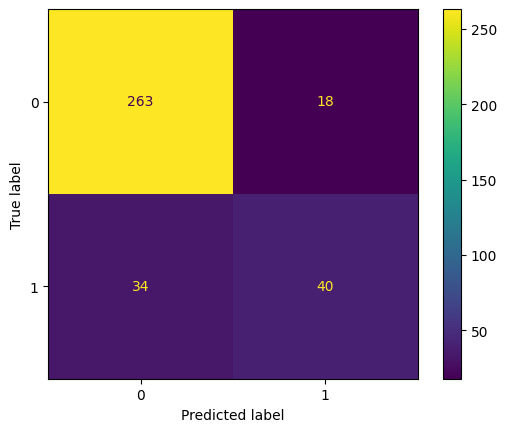

In [24]:
cm = confusion_matrix (test_df['category'], y_bert)
cm_display = ConfusionMatrixDisplay (cm).plot()

In [30]:
classic_results = pd.read_excel('classic_models_results.xlsx', index_col = 0)

In [31]:
results_report = []

In [32]:
def scores (model, y_test, y_pred):
  report_dict = classification_report(y_test, y_pred, output_dict=True)
  accuracy = report_dict['accuracy']
  f1_macro = report_dict['macro avg']['f1-score'] #больше всего нас интересует эта метрика, тк есть дисбаланс классов
  precision = report_dict ['macro avg']['precision']
  recall = report_dict ['macro avg']['recall']
  results_report.append ([model, accuracy, f1_macro, precision, recall])
  return results_report

In [33]:
scores ('BERT', test_df['category'], y_bert)

[['BERT',
  0.8535211267605634,
  0.7580476040683652,
  0.7875885289678393,
  0.7382418005193806]]

In [34]:
results_table = pd.DataFrame (results_report, columns=['model', 'accuracy', 'f1_macro', 'precision', 'recall'])
final_results = pd.concat ([classic_results, results_table], axis = 0, ignore_index=True)
final_results.sort_values(by='f1_macro', ascending=False)

,model,accuracy,f1_macro,precision,recall
7,BERT,0.853521,0.758048,0.787589,0.738242
2,LinearSVC,0.833803,0.738935,0.748678,0.730764
0,LogisticRegression,0.808451,0.730412,0.717610,0.749591
6,Stacking (SVC_LR_RF),0.845070,0.722376,0.787814,0.693085
3,ComplementNB,0.797183,0.719294,0.705511,0.742474
5,RandomForest_Balanced,0.785915,0.712930,0.697667,0.745311
1,LogisticRegression + BERTopic,0.783099,0.698559,0.686592,0.718645
4,RandomForest,0.833803,0.664993,0.799556,0.636193
